# Detekcija laznih oglasa za posao

U ovom projektu analiziramo kvalitet tekstualnih podataka i ispitujemo kako razlicite tehnike predobrade uticu na klasifikaciju oglasa na `real` i `fake`.

Notebook je organizovan kroz tri celine: pregled skupa podataka, pripremu teksta i poredjenje modela na vise varijanti ulaznog teksta.


In [106]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)
from nltk.stem import PorterStemmer


## Pregled skupa podataka

U ovom delu upoznajemo strukturu skupa podataka, raspodelu klasa i osnovne osobine tekstualnih opisa koji ce biti korisceni u klasifikaciji.


In [ ]:
DATASET_PATH = "fake_real_job_postings.csv"

df = pd.read_csv(DATASET_PATH)

text_cols = ['job_description', 'requirements', 'benefits', 'company_profile']

df['suspicious_email'] = df['contact_email'].str.contains('gmail|yahoo|outlook|proton', case=False, na=False).astype(int)
df['missing_website'] = df['company_website'].isnull().astype(int)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (3000, 27)


,job_id,job_title,job_description,requirements,benefits,company_name,company_profile,industry,employment_type,location,...,company_website,has_logo,num_open_positions,job_function,telecommuting,fraud_reason,text_length,is_fake,suspicious_email,missing_website
0,1,Data Analyst,Successful candidates communicate clearly with...,"THE WORK REQUIRES ATTENTION TO DETAIL, CLEAR H...","Bonus eligibility depends on team results, del...",BrightPath Solutions,Teams are small enough for direct collaboratio...,Software,Part-time,"Budapest, Hungary",...,https://www.brightpathsolutions.eu,1,3,Analysis,0,NaN,1634,0,0,0
1,2,Content Strategist,"The work requires attention to detail, clear h...",Candidates should be comfortable learning inte...,Flexible working hours with agreed core collab...,OakLine Holdings,Our recruiters may represent more than one con...,Logistics,Internship,Remote,...,https://www.oaklineholdings.co,1,1,Design,1,NaN,1558,0,0,0
2,3,Data Analyst,Successful candidates communicate clearly with...,Candidates should be comfortable learning inte...,MANAGER SUPPORT DURING ONBOARDING AND ACCESS T...,SilverFern Holdings,The company builds long-term client relationsh...,Human Resources,Part-time,"Novi Sad, Serbia",...,https://www.silverfernholdings.eu,1,2,Analysis,0,NaN,1679,0,0,0
3,4,Software Engineer,We are looking for someone who can balance day...,Our team works in short planning cycles and us...,"Bonus eligibility depends on team results, del...",OakLine Collective,Current growth has outpaced some internal syst...,Education,Full-time,"Berlin, Germany",...,https://www.oaklinecollective.eu,1,3,Development,0,NaN,1529,0,0,0
4,5,Data Analyst,Candidates should be comfortable learning inte...,You will partner with cross-functional te@mmat...,A mix of independent work and regular team che...,BlueCedar Solutions,Our Recruiters May Represent More Than One Con...,Education,Full-time,"Budapest, Hungary",...,https://www.bluecedarsolutions.rs,1,1,Analysis,0,NaN,1904,1,0,0


In [108]:
df.shape

(3000, 27)

In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   job_id                     3000 non-null   int64
 1   job_title                  3000 non-null   str  
 2   job_description            3000 non-null   str  
 3   requirements               3000 non-null   str  
 4   benefits                   3000 non-null   str  
 5   company_name               3000 non-null   str  
 6   company_profile            3000 non-null   str  
 7   industry                   3000 non-null   str  
 8   employment_type            3000 non-null   str  
 9   location                   3000 non-null   str  
 10  salary_range               3000 non-null   str  
 11  required_experience_years  3000 non-null   int64
 12  education_level            3000 non-null   str  
 13  department                 3000 non-null   str  
 14  posting_date               3000 non

In [110]:
df.isnull().sum()

job_id                          0
job_title                       0
job_description                 0
requirements                    0
benefits                        0
company_name                    0
company_profile                 0
industry                        0
employment_type                 0
location                        0
salary_range                    0
required_experience_years       0
education_level                 0
department                      0
posting_date                    0
application_deadline            0
contact_email                   0
company_website               380
has_logo                        0
num_open_positions              0
job_function                    0
telecommuting                   0
fraud_reason                 2804
text_length                     0
is_fake                         0
suspicious_email                0
missing_website                 0
dtype: int64

In [111]:
df['is_fake'].value_counts()


is_fake
0    1500
1    1500
Name: count, dtype: int64

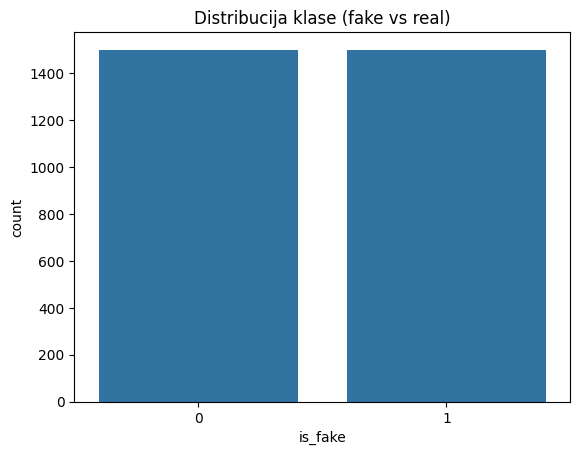

In [112]:
sns.countplot(x='is_fake', data=df)
plt.title("Distribucija klase (fake vs real)")
plt.show()


In [113]:
text_columns = ['job_description', 'requirements', 'benefits', 'company_profile']

df['full_text'] = df[text_columns].fillna('').agg(' '.join, axis=1)

df[['full_text']].head()


,full_text
0,Successful candidates communicate clearly with...
1,"The work requires attention to detail, clear h..."
2,Successful candidates communicate clearly with...
3,We are looking for someone who can balance day...
4,Candidates should be comfortable learning inte...


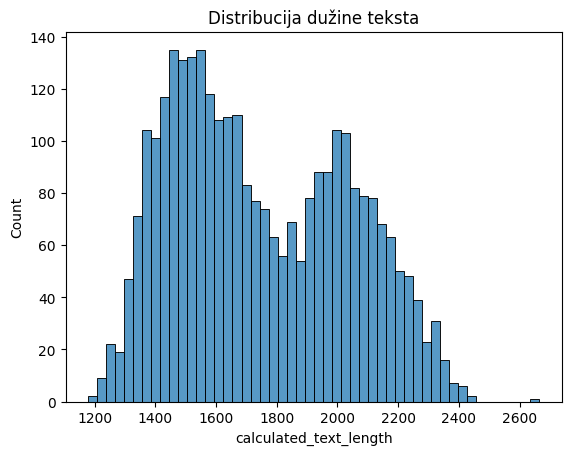

In [114]:
df['calculated_text_length'] = df['full_text'].apply(len)

sns.histplot(df['calculated_text_length'], bins=50)
plt.title("Distribucija dužine teksta")
plt.show()


In [115]:
all_words = ' '.join(df['full_text']).split()
vocab_size = len(set(all_words))


print("Vocabulary size:", vocab_size)


Vocabulary size: 2647


In [116]:
def lexical_diversity(text):
    words = text.split()
    return len(set(words)) / len(words) if len(words) > 0 else 0

df['lexical_diversity'] = df['full_text'].apply(lexical_diversity)

df['lexical_diversity'].describe()


count    3000.000000
mean        0.708616
std         0.067841
min         0.518018
25%         0.658600
50%         0.702880
75%         0.762648
max         0.924731
Name: lexical_diversity, dtype: float64

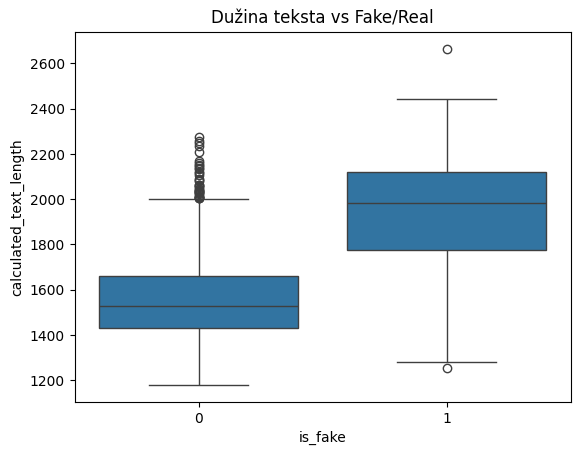

In [117]:
sns.boxplot(x='is_fake', y='calculated_text_length', data=df)
plt.title("Dužina teksta vs Fake/Real")
plt.show()


## Predobrada teksta

U ovom delu formiramo vise verzija istog teksta kako bismo uporedili uticaj osnovne normalizacije, uklanjanja stop-reci i stemminga na rezultate klasifikacije.


In [119]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['normalized_text'] = df['full_text'].apply(normalize_text)


In [120]:
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

df['no_stopwords_text'] = df['normalized_text'].apply(remove_stopwords)


In [121]:
# stemming

stemmer = PorterStemmer()

def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

df['stemmed_text'] = df['no_stopwords_text'].apply(stem_text)


In [122]:
preview = pd.DataFrame(
    {
        "raw": [df.loc[0, 'full_text'][:180]],
        "normalized": [df.loc[0, 'normalized_text'][:180]],
        "no_stopwords": [df.loc[0, 'no_stopwords_text'][:180]],
        "stemmed": [df.loc[0, 'stemmed_text'][:180]],
    }
)

preview.T


,0
raw,Successful candidates communicate clearly with...
normalized,successful candidates communicate clearly with...
no_stopwords,successful candidates communicate clearly stak...
stemmed,success candid commun clearli stakehold ask go...


## Modeli i evaluacija

Ovde poredimo performanse modela `LogisticRegression` i `MultinomialNB` nad razlicitim varijantama teksta. Posmatramo metrike `accuracy`, `precision`, `recall` i `F1`, kao i konfuzionu matricu za najbolju kombinaciju.


In [124]:
TEXT_VARIANTS = {
    "Raw text": "full_text",
    "Normalized text": "normalized_text",
    "Without stopwords": "no_stopwords_text",
    "Stemmed text": "stemmed_text",
}


def prepare_dataset(frame):
    prepared = frame.copy()
    text_columns = ['job_description', 'requirements', 'benefits', 'company_profile']
    prepared['full_text'] = prepared[text_columns].fillna('').agg(' '.join, axis=1)
    prepared['normalized_text'] = prepared['full_text'].apply(normalize_text)
    prepared['no_stopwords_text'] = prepared['normalized_text'].apply(remove_stopwords)
    prepared['stemmed_text'] = prepared['no_stopwords_text'].apply(stem_text)
    return prepared


def evaluate_model(frame, text_column, model_name):
    X = frame[text_column]
    y = frame['is_fake']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=48, stratify=y
    )

    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    if model_name == "LogisticRegression":
        model = LogisticRegression(max_iter=3000)
    elif model_name == "MultinomialNB":
        model = MultinomialNB()
    else:
        raise ValueError(f"Nepoznat model: {model_name}")

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    return {
        "Model": model_name,
        "Text variant": text_column,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Confusion matrix": confusion_matrix(y_test, y_pred),
        "Classification report": classification_report(y_test, y_pred),
    }


prepared_df = prepare_dataset(df)


In [125]:
experiment_rows = []

for model_name in ["LogisticRegression", "MultinomialNB"]:
    for variant_name, column_name in TEXT_VARIANTS.items():
        result = evaluate_model(prepared_df, column_name, model_name)
        result["Text variant"] = variant_name
        experiment_rows.append(result)

results_df = pd.DataFrame(experiment_rows)
results_df[["Model", "Text variant", "Accuracy", "Precision", "Recall", "F1"]].sort_values(
    by=["Model", "F1"], ascending=[True, False]
).reset_index(drop=True)


,Model,Text variant,Accuracy,Precision,Recall,F1
0,LogisticRegression,Stemmed text,0.850000,0.920000,0.766667,0.836364
1,LogisticRegression,Raw text,0.846667,0.912698,0.766667,0.833333
2,LogisticRegression,Without stopwords,0.846667,0.916000,0.763333,0.832727
3,LogisticRegression,Normalized text,0.845000,0.912351,0.763333,0.831216
4,MultinomialNB,Raw text,0.846667,0.922764,0.756667,0.831502
5,MultinomialNB,Normalized text,0.846667,0.922764,0.756667,0.831502
6,MultinomialNB,Without stopwords,0.846667,0.922764,0.756667,0.831502
7,MultinomialNB,Stemmed text,0.846667,0.922764,0.756667,0.831502


In [126]:
logreg_results = results_df[results_df["Model"] == "LogisticRegression"].copy()
logreg_results["Improvement_vs_raw"] = logreg_results["Accuracy"] - logreg_results.loc[
    logreg_results["Text variant"] == "Raw text", "Accuracy"
].iloc[0]

logreg_results[["Text variant", "Accuracy", "Precision", "Recall", "F1", "Improvement_vs_raw"]].sort_values(
    by="Accuracy", ascending=False
).reset_index(drop=True)


,Text variant,Accuracy,Precision,Recall,F1,Improvement_vs_raw
0,Stemmed text,0.850000,0.920000,0.766667,0.836364,0.003333
1,Raw text,0.846667,0.912698,0.766667,0.833333,0.000000
2,Without stopwords,0.846667,0.916000,0.763333,0.832727,0.000000
3,Normalized text,0.845000,0.912351,0.763333,0.831216,-0.001667


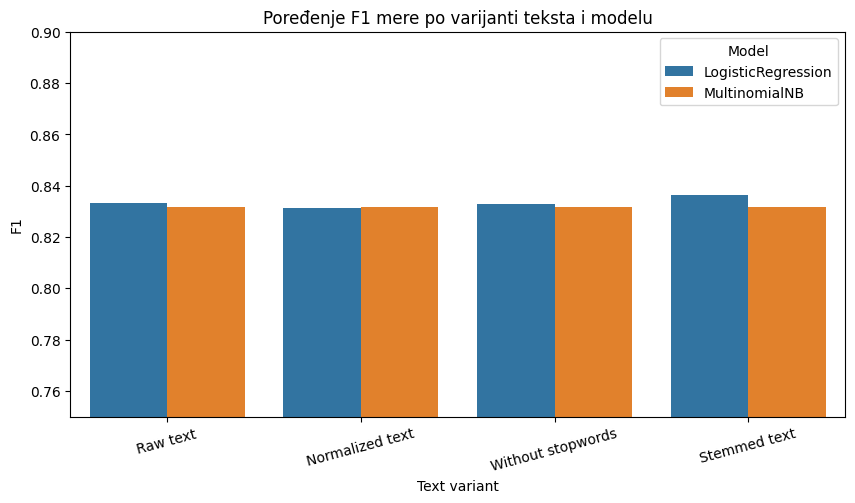

In [127]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Text variant", y="F1", hue="Model")
plt.title("Poređenje F1 mere po varijanti teksta i modelu")
plt.xticks(rotation=15)
plt.ylim(0.75, 0.9)
plt.show()


In [128]:
best_row = results_df.sort_values(by="F1", ascending=False).iloc[0]
best_row[["Model", "Text variant", "Accuracy", "Precision", "Recall", "F1"]]


Model           LogisticRegression
Text variant          Stemmed text
Accuracy                      0.85
Precision                     0.92
Recall                    0.766667
F1                        0.836364
Name: 3, dtype: object

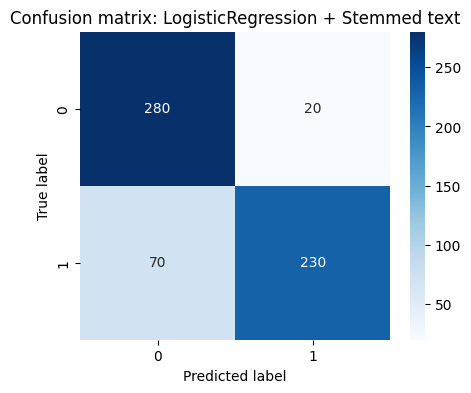

              precision    recall  f1-score   support

           0       0.80      0.93      0.86       300
           1       0.92      0.77      0.84       300

    accuracy                           0.85       600
   macro avg       0.86      0.85      0.85       600
weighted avg       0.86      0.85      0.85       600



In [129]:
best_confusion_matrix = best_row["Confusion matrix"]

plt.figure(figsize=(5, 4))
sns.heatmap(best_confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion matrix: {best_row['Model']} + {best_row['Text variant']}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

print(best_row["Classification report"])


### Kratak zakljucak

- Najpre analiziramo strukturu i osnovne osobine tekstova u skupu podataka.
- Zatim formiramo vise varijanti teksta kroz jednostavne korake predobrade.
- Na kraju uporedjujemo modele i izdvajamo kombinaciju koja daje najbolje rezultate na zadatku klasifikacije.
